# SimCLR Analysis

Comprehensive analysis of a SimCLR model pretrained on STL-10 (96x96 images).

**Sections:**
- **A. Training Trajectories** -- loss, k-NN accuracy, and learning rate over epochs
- **B. Evaluation Results** -- k-NN sweep and linear probe (full + low-data)
- **C. Intermediate Layer Feature Maps** -- visualize ResNet-18 layer activations
- **D. SimCLR-Specific** -- augmented view pairs and t-SNE of learned features

In [1]:
import sys
from pathlib import Path
import json
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import transforms, datasets
from sklearn.manifold import TSNE

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from models.simclr import SimCLR, SimCLRAugmentation
from evaluation import extract_features
from evaluation.knn import knn_classify
from evaluation.linear_probe import LinearProbe
from utils.data import get_eval_loaders, STL10_MEAN, STL10_STD, DATA_DIR

sns.set_theme(style="whitegrid", font_scale=1.1)
device = "cuda" if torch.cuda.is_available() else "cpu"
CLASS_NAMES = ["airplane", "bird", "car", "cat", "deer", "dog", "horse", "monkey", "ship", "truck"]
RESULTS_DIR = PROJECT_ROOT / "results" / "simclr"

print(f"Device: {device}")
print(f"Results dir: {RESULTS_DIR}")

Device: cuda
Results dir: /home/justinas/ssl_image_method_comparison/results/simclr


## A. Training Trajectories

Load the training history and plot loss, k-NN accuracy, and learning rate schedule over epochs.

In [2]:
with open(RESULTS_DIR / "history.json") as f:
    history = json.load(f)

epochs = [h["epoch"] for h in history]
losses = [h["loss"] for h in history]
knn_accs = [h["knn_top1"] for h in history]
lrs = [h["lr"] for h in history]

print(f"Training epochs: {len(history)}")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Best k-NN accuracy: {max(knn_accs):.4f} (epoch {epochs[np.argmax(knn_accs)]})")

Training epochs: 100
Final loss: 4.4365
Best k-NN accuracy: 0.8046 (epoch 429)


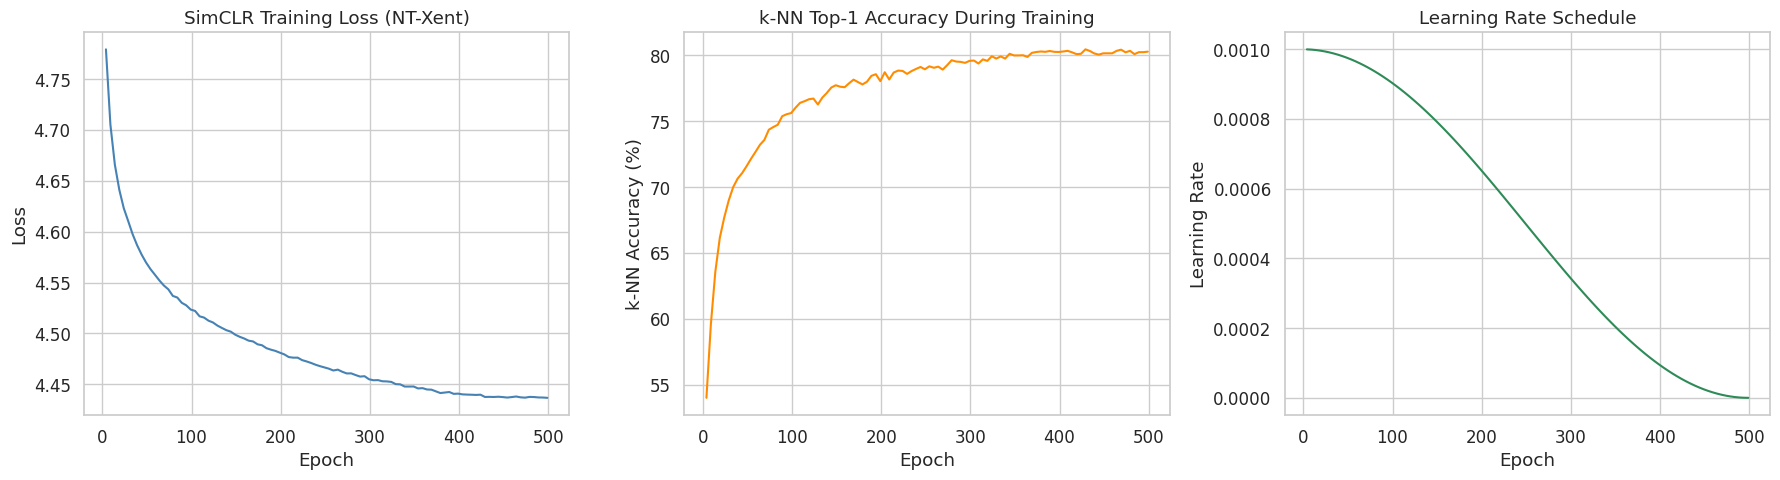

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
axes[0].plot(epochs, losses, color="steelblue")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("SimCLR Training Loss (NT-Xent)")

# k-NN accuracy curve
axes[1].plot(epochs, [a * 100 for a in knn_accs], color="darkorange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("k-NN Accuracy (%)")
axes[1].set_title("k-NN Top-1 Accuracy During Training")

# Learning rate schedule
axes[2].plot(epochs, lrs, color="seagreen")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_title("Learning Rate Schedule")

plt.tight_layout()
plt.show()

## B. Evaluation Results

Load the trained SimCLR model, extract features using the encoder (before projection head), and evaluate with k-NN and linear probe.

In [4]:
# Load pre-computed evaluation results across all checkpoints
with open(PROJECT_ROOT / "results" / "all_eval_results.json") as f:
    all_results = json.load(f)

sc_results = sorted(
    [r for r in all_results if r["method"] == "simclr" and r["checkpoint_name"].startswith("checkpoint_")],
    key=lambda r: r["epoch"],
)

eval_epochs = [r["epoch"] for r in sc_results]
eval_knn20 = [r["knn"]["20"] for r in sc_results]
eval_probe = [r["linear_probe"] for r in sc_results]
eval_probe_low = [r["linear_probe_lowdata"] for r in sc_results]

print(f"Loaded {len(sc_results)} checkpoint evaluations")

Loaded 10 checkpoint evaluations


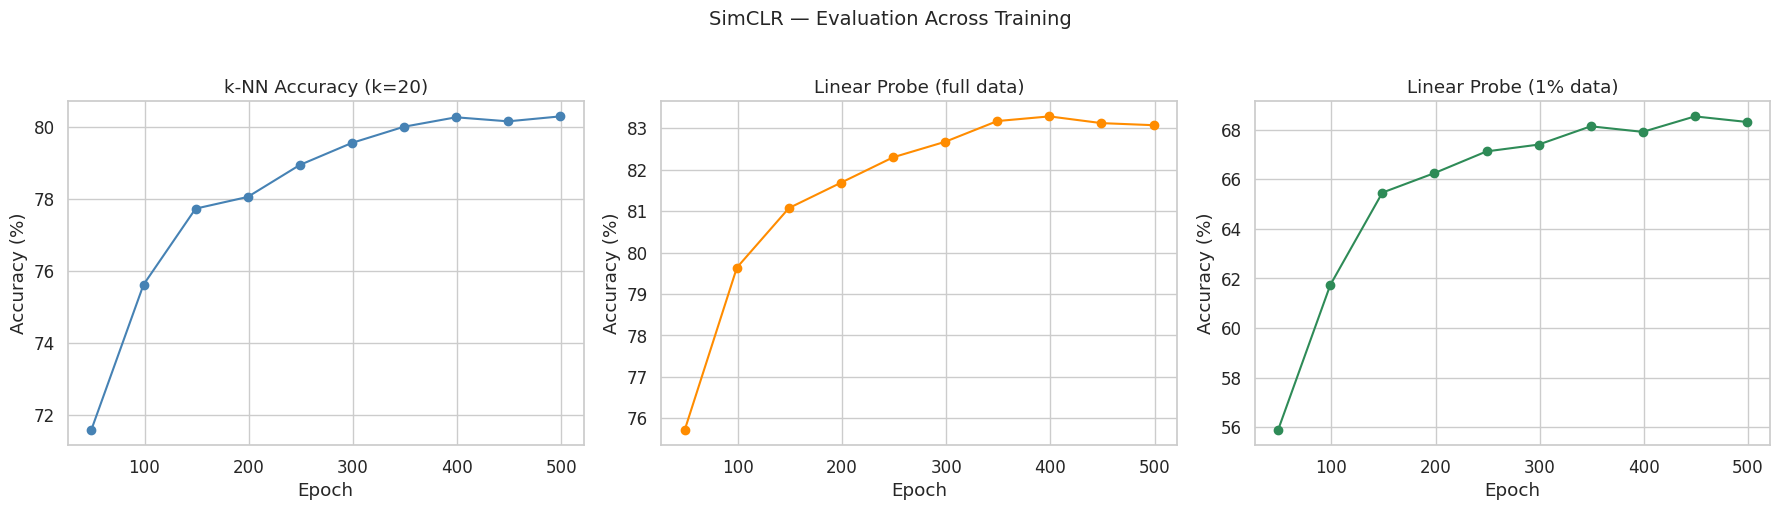

In [5]:
# Evaluation metrics across training
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(eval_epochs, [a * 100 for a in eval_knn20], "o-", color="steelblue")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("k-NN Accuracy (k=20)")

axes[1].plot(eval_epochs, [a * 100 for a in eval_probe], "o-", color="darkorange")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Linear Probe (full data)")

axes[2].plot(eval_epochs, [a * 100 for a in eval_probe_low], "o-", color="seagreen")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Accuracy (%)")
axes[2].set_title("Linear Probe (1% data)")

fig.suptitle("SimCLR — Evaluation Across Training", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

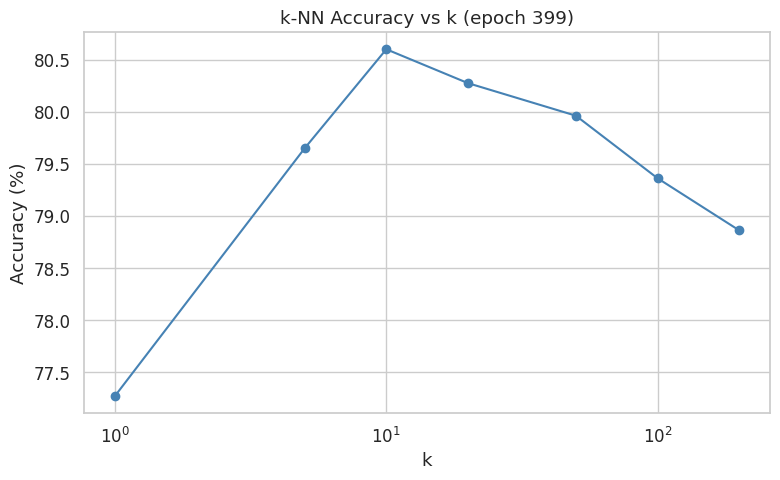

In [6]:
# k-NN accuracy vs k for the best checkpoint (by linear probe)
best_idx = int(np.argmax(eval_probe))
best_result = sc_results[best_idx]
best_knn = best_result["knn"]

fig, ax = plt.subplots(figsize=(8, 5))
k_vals = [int(k) for k in best_knn.keys()]
accs = [best_knn[str(k)] * 100 for k in k_vals]
ax.plot(k_vals, accs, "o-", color="steelblue")
ax.set_xscale("log"); ax.set_xlabel("k"); ax.set_ylabel("Accuracy (%)")
ax.set_title(f"k-NN Accuracy vs k (epoch {best_result['epoch']})")
plt.tight_layout()
plt.show()

In [7]:
# Summary table
print(f"{'Checkpoint':<25s} {'Epoch':>6s} {'k-NN(20)':>10s} {'Probe':>10s} {'Probe(1%)':>10s}")
print("-" * 63)
for r in sc_results:
    marker = " <-- best" if r is best_result else ""
    print(f"{r['checkpoint_name']:<25s} {r['epoch']:>6d} "
          f"{r['knn']['20']*100:>9.2f}% {r['linear_probe']*100:>9.2f}% "
          f"{r['linear_probe_lowdata']*100:>9.2f}%{marker}")

Checkpoint                 Epoch   k-NN(20)      Probe  Probe(1%)
---------------------------------------------------------------
checkpoint_0049.pt            49     71.60%     75.72%     55.90%
checkpoint_0099.pt            99     75.62%     79.64%     61.74%
checkpoint_0149.pt           149     77.74%     81.08%     65.46%
checkpoint_0199.pt           199     78.06%     81.69%     66.25%
checkpoint_0249.pt           249     78.95%     82.30%     67.12%
checkpoint_0299.pt           299     79.56%     82.67%     67.40%
checkpoint_0349.pt           349     80.01%     83.17%     68.14%
checkpoint_0399.pt           399     80.27%     83.29%     67.91% <-- best
checkpoint_0449.pt           449     80.16%     83.12%     68.54%
checkpoint_0499.pt           499     80.30%     83.08%     68.31%


## C. Intermediate Layer Feature Maps

Visualize activations from each ResNet-18 layer (layer1 through layer4) for a single test image. Each layer shows the first 16 channels as a 4x4 grid.

In [8]:
# Load model (best by linear probe) and data for visualization sections
best_ckpt_path = RESULTS_DIR / best_result["checkpoint_name"]
ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=True)
ckpt_args = ckpt["args"]
model = SimCLR(
    backbone=ckpt_args.get("backbone", "resnet18"),
    proj_output_dim=ckpt_args.get("proj_dim", 128),
    temperature=ckpt_args.get("temperature", 0.5),
)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device).eval()

loaders = get_eval_loaders(batch_size=256)

# Extract features for t-SNE (Section D)
train_features, train_labels = extract_features(model.encoder, loaders["train"], device)

print(f"Loaded SimCLR from epoch {best_result['epoch']}")

Loaded SimCLR from epoch 399


In [9]:
# Register forward hooks on each ResNet-18 layer
activations = {}

def make_hook(name):
    def hook(module, input, output):
        activations[name] = output.detach().cpu()
    return hook

hooks = []
for name in ["layer1", "layer2", "layer3", "layer4"]:
    h = getattr(model.encoder, name).register_forward_hook(make_hook(name))
    hooks.append(h)

# Get a single test image
test_ds = loaders["test"].dataset
test_img, test_label = test_ds[0]

# Forward pass to collect activations
with torch.no_grad():
    model.encoder(test_img.unsqueeze(0).to(device))

# Remove hooks
for h in hooks:
    h.remove()

# Print activation shapes
layer_names = ["layer1", "layer2", "layer3", "layer4"]
for name in layer_names:
    print(f"{name}: {tuple(activations[name].shape)}")

layer1: (1, 64, 24, 24)
layer2: (1, 128, 12, 12)
layer3: (1, 256, 6, 6)
layer4: (1, 512, 3, 3)


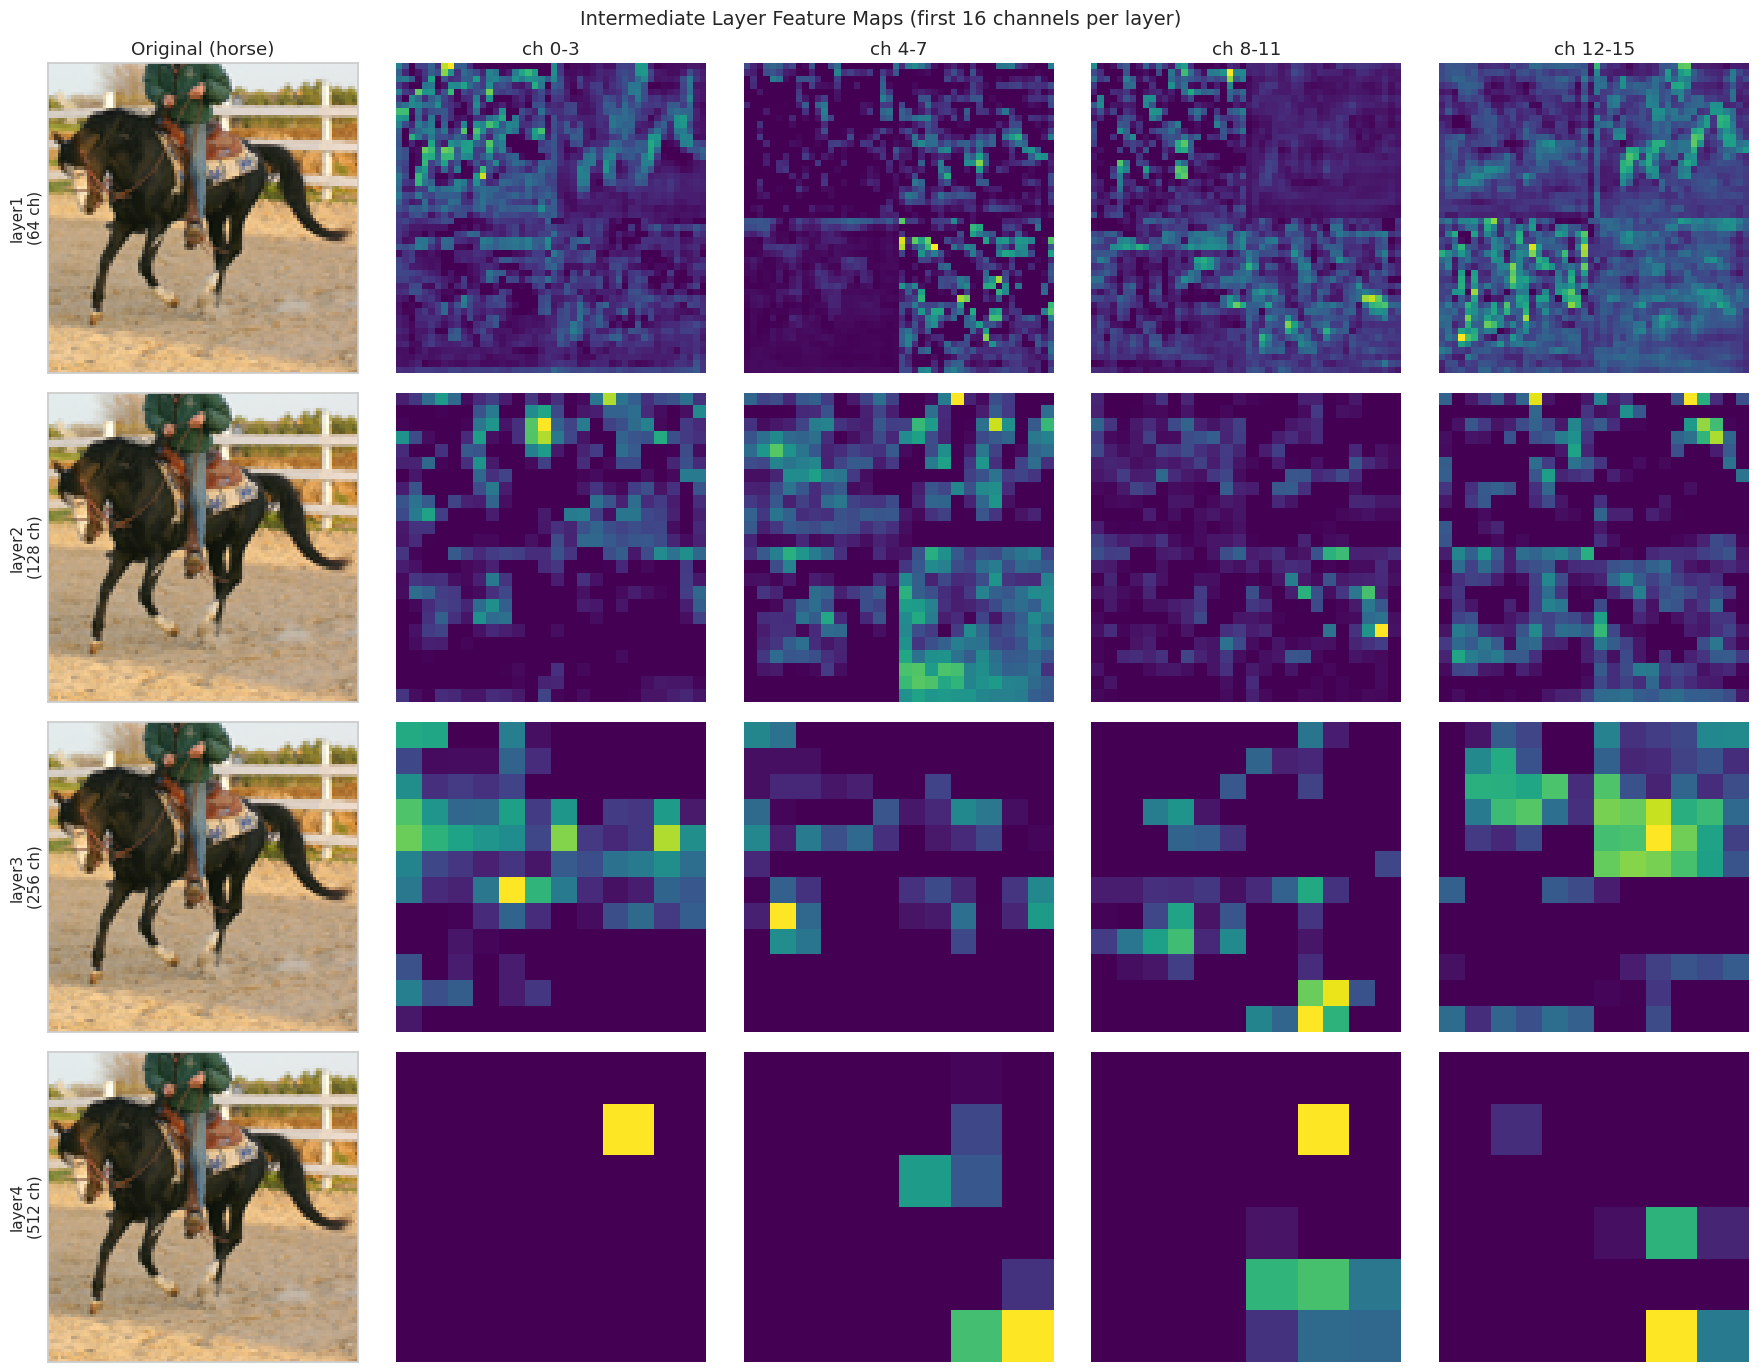

In [10]:
def denormalize(tensor, mean=STL10_MEAN, std=STL10_STD):
    t = tensor.clone()
    for i, (m, s) in enumerate(zip(mean, std)):
        t[i].mul_(s).add_(m)
    return t.clamp(0, 1)

orig_img = denormalize(test_img).permute(1, 2, 0).numpy()
layer_channels = [64, 128, 256, 512]

fig, axes = plt.subplots(4, 5, figsize=(18, 14))

for row, (name, n_ch) in enumerate(zip(layer_names, layer_channels)):
    act = activations[name][0]  # (C, H, W)

    # Column 0: original image
    axes[row, 0].imshow(orig_img)
    axes[row, 0].set_title(f"Original ({CLASS_NAMES[test_label]})" if row == 0 else "")
    axes[row, 0].set_ylabel(f"{name}\n({n_ch} ch)", fontsize=11)
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

    # Columns 1-4: 16 channels arranged as four 2x2 grids
    for col in range(4):
        ch_start = col * 4
        grid_rows = []
        for r in range(2):
            grid_cols = []
            for c in range(2):
                ch = ch_start + r * 2 + c
                grid_cols.append(act[ch].numpy())
            grid_rows.append(np.concatenate(grid_cols, axis=1))
        grid = np.concatenate(grid_rows, axis=0)
        axes[row, col + 1].imshow(grid, cmap="viridis")
        axes[row, col + 1].set_title(f"ch {ch_start}-{ch_start+3}" if row == 0 else "")
        axes[row, col + 1].axis("off")

plt.suptitle("Intermediate Layer Feature Maps (first 16 channels per layer)", fontsize=14)
plt.tight_layout()
plt.show()

## D. SimCLR-Specific -- Augmented Views + t-SNE

### Augmented View Pairs

Show 4 images from the test set alongside their two augmented views produced by `SimCLRAugmentation()`.

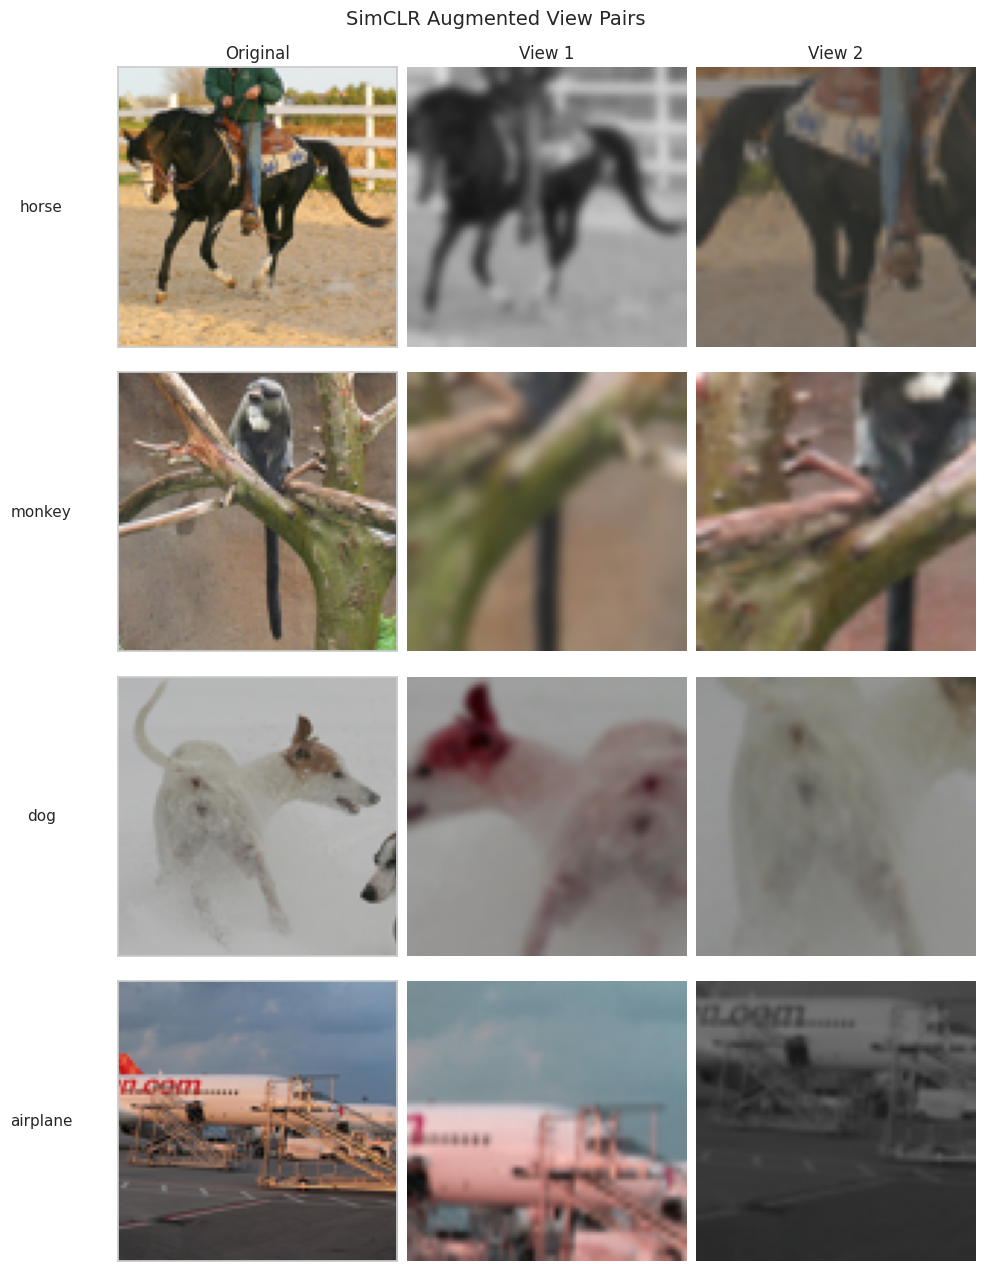

In [11]:
# Load raw PIL images for display and augmentation
raw_test_ds = datasets.STL10(root=str(DATA_DIR), split="test", download=False)
aug = SimCLRAugmentation()

fig, axes = plt.subplots(4, 3, figsize=(10, 13))
axes[0, 0].set_title("Original", fontsize=12)
axes[0, 1].set_title("View 1", fontsize=12)
axes[0, 2].set_title("View 2", fontsize=12)

for i in range(4):
    pil_img, label = raw_test_ds[i]
    view1, view2 = aug(pil_img)

    # Display original (convert PIL to tensor for display)
    axes[i, 0].imshow(pil_img)
    axes[i, 0].set_ylabel(CLASS_NAMES[label], fontsize=11, rotation=0, labelpad=55, va="center")
    axes[i, 0].set_xticks([])
    axes[i, 0].set_yticks([])

    # Display augmented views (denormalize since SimCLRAugmentation applies normalization)
    axes[i, 1].imshow(denormalize(view1).permute(1, 2, 0).numpy())
    axes[i, 1].axis("off")

    axes[i, 2].imshow(denormalize(view2).permute(1, 2, 0).numpy())
    axes[i, 2].axis("off")

plt.suptitle("SimCLR Augmented View Pairs", fontsize=14)
plt.tight_layout()
plt.show()

### t-SNE of Learned Features

Visualize the 2D t-SNE embedding of SimCLR encoder features from the training set, colored by class label.

In [12]:
# Use the already-extracted train features (first 2000 samples)
n_subset = 2000
subset_feats = train_features[:n_subset].numpy()
subset_labels = train_labels[:n_subset].numpy()

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings = tsne.fit_transform(subset_feats)

print(f"t-SNE embedding shape: {embeddings.shape}")
print(f"Samples: {n_subset}, Classes: {len(np.unique(subset_labels))}")

t-SNE embedding shape: (2000, 2)
Samples: 2000, Classes: 10


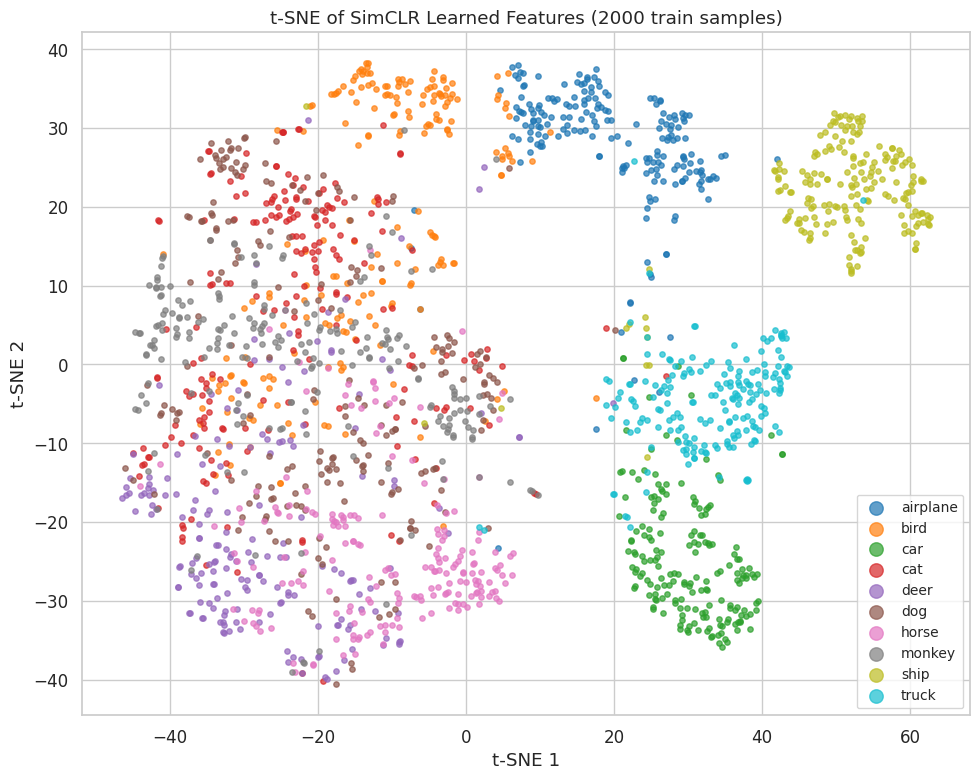

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.cm.tab10

for class_idx in range(10):
    mask = subset_labels == class_idx
    ax.scatter(
        embeddings[mask, 0], embeddings[mask, 1],
        c=[cmap(class_idx)], label=CLASS_NAMES[class_idx],
        s=15, alpha=0.7,
    )

ax.legend(markerscale=2.5, fontsize=10, loc="best")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE of SimCLR Learned Features (2000 train samples)")
plt.tight_layout()
plt.show()